# [9660] Homework 5 - Multi-model
Data file: https://raw.githubusercontent.com/vjavaly/Baruch-CIS-9660/main/data/Framingham_heart_disease_4000.csv

## Homework Submission Rules (for all homework assignments)
* Homework is due by 6:05 PM on the due date
  * No late submission will be accepted
* You must submit a cleanly executed notebook (*.ipynb)
  * Verify that you are submitting the correct homework file
* Homework file naming convention
  * LastName_FirstName_HwX.ipynb  [Replace X with the homework #]
    * 1 point deducted for submitting homework not complying with naming convention
* Before submission, execute "Kernel -> Restart Kernel and Run All Cells"
  * 1 point deducted for not submitting a cleanly executed notebook

## Homework 5 Requirements
* Load data
* Examine data
  * Display (e.g. bar chart) class distribution of target variable (TenYearCHD)
* Prepare data for model training
  * Perform the following data preparation steps
    * Handle missing values
    * Variable encoding
    * Feature scaling
    * Principal component analysis (PCA)
      * NOTE: Binary variables are not ideal for Principal Component Analysis (PCA), particularly because PCA is designed for continuous, normally distributed data  
  * Do not delete any rows
  * Do not drop any columns, EXCEPT when performing variable encoding and PCA
* Display a sample of 20 rows of the final set of independent variables used for all the model trainings
* Train logistic regression model
  * Must set **class_weight** hyperparameter AND at least 1 other hyperparameter (not including random_state)
    * The hyperparameter values you set CANNOT be the same as the defaults
    * You can modify as many hyperparameters as your want
  * Calculate and display model accuracy
    * **NOTE: Logistic regression model accuracy must exceed 65%**
* Train the following classification models (KNN, Random Forest & SVC).  For the SVC model, you can use any SVC classifier.  Perform the following for each model:
  * Must modify at least 2 hyperparameters (not including random_state) in each model
    * The hyperparameter values you set CANNOT be the same as the defaults
    * You can modify as many hyperparameters as your want
    * For random forest and SVC, use the same class_weight hyperparameter value used for logistic regression
    * If you used hyperparameter random_state in your Logistic Regression model training, use the same value when training the other models
    * Do NOT re-split training and test sets when training the other models
  * Calculate and display this model's accuracy
    * **NOTE: For each of these 3 classification models, model accuracy MUST exceed 80%**
* Display (e.g. bar chart) model accuracy for all 4 models

#### NOTES
- You must TRY to resolve all errors and warnings
- You may set random_state hyperparameter to control the accuracy output

In [1]:
from datetime import datetime
print(f'Run time: {datetime.now().strftime("%D %T")}')

Run time: 12/12/24 20:29:59


### Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Add other imports as needed
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn import decomposition

### Load data

Objective  
> Predict if a patient has a 10-year risk of developing coronary heart disease (CHD).

Problem  
> The World Health Organization has estimated 12 million deaths occur worldwide, every year due to Heart diseases. Half the deaths in the United States and other developed countries are due to cardio vascular diseases. The early prognosis of cardiovascular diseases can aid in making decisions on lifestyle changes in high risk patients and in turn reduce the complications. This research intends to pinpoint the most relevant/risk factors of heart disease as well as predict the overall risk using logistic regression Data Preparation

Source
> The source dataset is publically available on the Kaggle website, and it is from an ongoing cardiovascular study on residents of the town of Framingham, Massachusetts. The classification goal is to predict whether the patient has 10-year risk of future coronary heart disease (CHD).The dataset provides the patients’ information. It includes over 4,000 records and 15 attributes. Variables Each attribute is a potential risk factor. There are both demographic, behavioral and medical risk factors.

> **NOTE: The professor has modified this dataset for the purposes of this assignment.  You must use this modified dataset for this homework.**

Demographic Attributes:
> gender: Male / Female  
> age: integer  
> attended_college: whether or not the patient attended college

Behavioral Attributes:
> currentSmoker: whether or not the patient is a current smoker  
> cigsPerDay: the number of cigarettes that the person smoked on average in one day

Medical History Attributes:
> BPMeds: whether or not the patient was on blood pressure medication  
> prevalentStroke: whether or not the patient had previously had a stroke  
> prevalentHyp: whether or not the patient was hypertensive  
> diabetes: whether or not the patient had diabetes.

Current Medical Condition Attributes (continuous variables):
> totChol: total cholesterol level  
> sysBP: systolic blood pressure  
> diaBP: diastolic blood pressure  
> BMI: Body Mass Index  
> heartRate: heart rate  
> glucose: glucose level  

Target variable to predict:
> TenYearCHD: 10 year risk of coronary heart disease (CHD)

In [3]:
# Read data from file (Framingham_heart_disease_4000.csv) into dataframe
chd = pd.read_csv('https://raw.githubusercontent.com/vjavaly/Baruch-CIS-9660/main/data/Framingham_heart_disease_4000.csv')

### Examine data

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
# Review dataframe shape
chd.shape

(4000, 16)

In [6]:
# Display a sample of 5 rows from dataframe
chd.sample(5)

,gender,age,attended_college,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
1108,Female,38,y,No,0.0,no,NO,no,N,185.0,100.0,72.0,22.15,85.0,83.0,N
981,Male,48,n,Yes,10.0,no,NO,no,N,308.0,117.0,76.0,30.85,65.0,54.0,Y
1537,Male,40,y,No,0.0,no,NO,no,N,209.0,123.5,83.0,28.06,72.0,63.0,N
1637,Male,60,n,No,0.0,no,NO,no,N,275.0,132.0,82.0,23.53,75.0,62.0,N
3180,Female,40,n,Yes,20.0,no,NO,no,N,237.0,130.0,72.0,23.54,75.0,80.0,N


### Display bar chart showing class distribution for target variable (TenYearCHD)

In [7]:
# Display class distribution counts
chd['TenYearCHD'].value_counts()

,count
TenYearCHD,
N,3402
Y,598


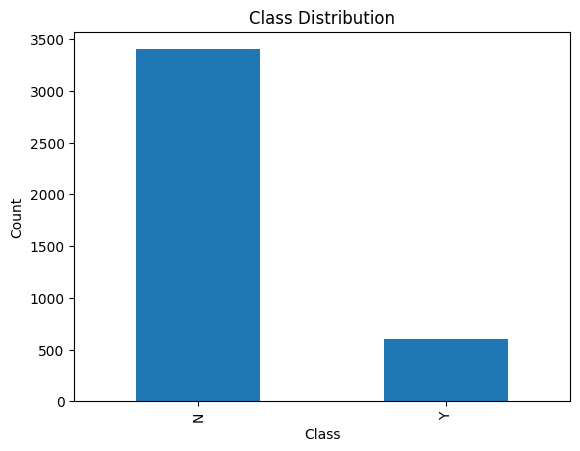

In [8]:
# Display bar chart showing class distribution
chd['TenYearCHD'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

### Prepare data for model training
* Do not delete any rows
* Do not drop any columns, EXCEPT when performing variable encoding and PCA

#### Check for missing values

In [9]:
chd.isnull().sum()

,0
gender,0
age,0
attended_college,100
currentSmoker,0
cigsPerDay,27
BPMeds,48
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,49


#### Use the SimpleImputer to replace missing values

In [10]:
#checking the datatype of columns which has missing values
chd.dtypes[['attended_college', 'cigsPerDay', 'BPMeds', 'totChol', 'BMI', 'glucose']]

,0
attended_college,object
cigsPerDay,float64
BPMeds,object
totChol,float64
BMI,float64
glucose,float64


In [11]:
# object strategy --> most_frequent
# float64 strategy --> mean

imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
cols_to_impute_1 = ['cigsPerDay', 'totChol', 'BMI', 'glucose']
chd[cols_to_impute_1] = imp_mean.fit_transform(chd[cols_to_impute_1])

imp_most_freq = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
cols_to_impute_2 = ['attended_college', 'BPMeds']
chd[cols_to_impute_2] = imp_most_freq.fit_transform(chd[cols_to_impute_2])

#### Check for missing values again

In [12]:
chd.isnull().sum()

,0
gender,0
age,0
attended_college,0
currentSmoker,0
cigsPerDay,0
BPMeds,0
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,0


### Perform variable encoding

In [13]:
# one-hot encode for columns 'gender', 'attended_college', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes'

columns_to_encode = ['gender', 'attended_college', 'currentSmoker', 'BPMeds',
                     'prevalentStroke', 'prevalentHyp', 'diabetes']

for column in columns_to_encode:
    print(f"{column}: {chd[column].unique()}")

gender: ['Male' 'Female']
attended_college: ['n' 'y']
currentSmoker: ['Yes' 'No']
BPMeds: ['yes' 'no']
prevalentStroke: ['NO' 'YES']
prevalentHyp: ['yes' 'no']
diabetes: ['N' 'Y']


In [14]:
# notice that there are variations in the values even though they have same meaning
# lets clean them up for better understanding

mapping = {'yes': 'yes', 'y': 'yes', 'no': 'no', 'n': 'no'}

for column in columns_to_encode:
    chd[column] = chd[column].str.lower().str.strip()
    chd[column] = chd[column].map(mapping)
    print(f"{column}: {chd[column].unique()}")

gender: [nan]
attended_college: ['no' 'yes']
currentSmoker: ['yes' 'no']
BPMeds: ['yes' 'no']
prevalentStroke: ['no' 'yes']
prevalentHyp: ['yes' 'no']
diabetes: ['no' 'yes']


In [15]:
# performing one-hot encoding on all the categorical independent variables
chd = pd.get_dummies(chd, columns=columns_to_encode, dtype=int)

In [16]:
# label encode the target variable
le = LabelEncoder()
chd['TenYearCHD'] = le.fit_transform(chd['TenYearCHD'])

In [17]:
chd.sample(5)

,age,cigsPerDay,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,attended_college_no,attended_college_yes,currentSmoker_no,currentSmoker_yes,BPMeds_no,BPMeds_yes,prevalentStroke_no,prevalentStroke_yes,prevalentHyp_no,prevalentHyp_yes,diabetes_no,diabetes_yes
3519,51,0.0,295.0,131.0,87.0,24.41,85.0,77.0,0,1,0,1,0,1,0,1,0,1,0,1,0
3610,49,0.0,211.0,103.5,66.5,24.17,75.0,87.0,1,1,0,1,0,1,0,1,0,1,0,1,0
147,60,0.0,335.0,199.0,83.0,24.61,80.0,90.0,0,1,0,1,0,1,0,1,0,0,1,1,0
3479,46,10.0,250.0,116.0,71.0,20.35,88.0,94.0,0,1,0,0,1,1,0,1,0,1,0,1,0
2495,47,30.0,143.0,114.0,79.0,26.59,69.0,72.0,1,1,0,0,1,1,0,1,0,1,0,1,0


### Separate independent and dependent variables
* Independent variables: All variables EXCEPT TenYearCHD
* Dependent variable: TenYearCHD

In [18]:
X = chd.drop('TenYearCHD', axis=1)
y = chd['TenYearCHD']

#### Standardize the independent variables

In [19]:
# dividing the X dataframe into two; for seperating PCA input and categorical columns
pca_columns = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
X_pca = X[pca_columns]
X_cat = X.drop(pca_columns, axis=1)

In [20]:
standard_scaler = StandardScaler()
X_pca_scaled = standard_scaler.fit_transform(X_pca)
X_cat_scaled = standard_scaler.fit_transform(X_cat)

### Perform principal component analysis (PCA)

In [21]:
# applying pca
pca = PCA(n_components=3, random_state=42)
X_pca_output = pca.fit_transform(X_pca_scaled)

# converting the pca output to a dataframe
X_pca_df = pd.DataFrame(X_pca_output, columns=[f'PC{i+1}' for i in range(X_pca_output.shape[1])])

In [22]:
# diaplying the ratio of components
ex_variance = np.var(X_pca_output, axis=0)
ex_variance_ratio = ex_variance/np.sum(ex_variance)
print(f"1st component ratio = {round(ex_variance_ratio[0],4)}")
print(f"2nd component ratio = {round(ex_variance_ratio[1],4)}")
print(f"3rd component ratio = {round(ex_variance_ratio[2],4)}")

1st component ratio = 0.5213
2nd component ratio = 0.2572
3rd component ratio = 0.2215


In [23]:
# lets convert the X_cat back to dataframe
X_cat_df = pd.DataFrame(X_cat_scaled, columns=X_cat.columns)

# combining pca output with the categorical columns
X_final = pd.concat([X_pca_df, X_cat_df], axis=1)

### Display a sample of 20 rows from the final set of independent variables used for all the model trainings

In [24]:
X_final.sample(20)

,PC1,PC2,PC3,attended_college_no,attended_college_yes,currentSmoker_no,currentSmoker_yes,BPMeds_no,BPMeds_yes,prevalentStroke_no,prevalentStroke_yes,prevalentHyp_no,prevalentHyp_yes,diabetes_no,diabetes_yes
2127,2.940352,-0.507782,0.223702,0.612793,-0.612793,0.984126,-0.984126,0.175863,-0.175863,0.079305,-0.079305,-1.492786,1.492786,0.163383,-0.163383
1860,0.314021,0.719675,-0.887773,0.612793,-0.612793,-1.016130,1.016130,0.175863,-0.175863,0.079305,-0.079305,0.669888,-0.669888,0.163383,-0.163383
1420,0.463704,-0.041628,-0.572734,-1.631871,1.631871,0.984126,-0.984126,0.175863,-0.175863,0.079305,-0.079305,0.669888,-0.669888,0.163383,-0.163383
2130,0.799719,1.689742,-0.247437,0.612793,-0.612793,0.984126,-0.984126,0.175863,-0.175863,0.079305,-0.079305,-1.492786,1.492786,0.163383,-0.163383
2599,4.313610,1.352751,-1.313196,0.612793,-0.612793,-1.016130,1.016130,0.175863,-0.175863,0.079305,-0.079305,-1.492786,1.492786,0.163383,-0.163383
162,-1.567840,-0.238161,0.654536,-1.631871,1.631871,-1.016130,1.016130,0.175863,-0.175863,0.079305,-0.079305,0.669888,-0.669888,0.163383,-0.163383
3691,-1.463149,-1.247923,-0.374268,0.612793,-0.612793,0.984126,-0.984126,0.175863,-0.175863,0.079305,-0.079305,0.669888,-0.669888,0.163383,-0.163383
3656,2.785972,-0.089265,-0.037371,-1.631871,1.631871,0.984126,-0.984126,0.175863,-0.175863,0.079305,-0.079305,-1.492786,1.492786,0.163383,-0.163383
3522,0.071772,0.349986,-0.468716,0.612793,-0.612793,-1.016130,1.016130,0.175863,-0.175863,0.079305,-0.079305,0.669888,-0.669888,0.163383,-0.163383
2864,-0.037629,-0.531691,-0.716875,0.612793,-0.612793,0.984126,-0.984126,0.175863,-0.175863,0.079305,-0.079305,0.669888,-0.669888,0.163383,-0.163383


### Display a sample of 5 rows from the final set of dependent variables used for all the model trainings

In [25]:
y.sample(5)

,TenYearCHD
1599,0
3515,0
88,0
3285,0
3080,0


### Split data into training and test sets

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y,stratify=y,
                                                    test_size=0.3, random_state=42)
# random_state is used for teaching purposes only

### Train Logistic Regression model
#### Must set **class_weight** hyperparameter AND at least 1 other hyperparameter (not including random_state)

In [27]:
LogReg_model = LogisticRegression(class_weight = 'balanced', C = 1.0, solver = 'liblinear')
LogReg_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', solver='liblinear')

### Evaluate Logistic Regression model

In [28]:
# Calculate and display model accuracy
predictions = LogReg_model.predict(X_test)

LogReg_accuracy = LogReg_model.score(X_test, y_test)
print("Logistic Regression Model Accuracy = ", round((LogReg_accuracy * 100), 3), "%")

Logistic Regression Model Accuracy =  66.583 %


### Train KNN classifier model
#### Must modify at least 2 hyperparameters (excluding random_state)

In [29]:
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
knn_model.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', weights='distance')

### Evaluate KNN model

In [30]:
# Calculate and display model accuracy
predictions = knn_model.predict(X_test)

knn_accuracy = knn_model.score(X_test, y_test)
print("knn Model Accuracy = ", round((knn_accuracy * 100), 3), "%")

knn Model Accuracy =  83.333 %


### Train Random Forest classifier model
#### Must use same **class_weight** hyperparameter value used for logistic regression and change at least 1 other hyperparameter (excluding random_state)

In [31]:
rf_model = RandomForestClassifier(n_estimators=300, class_weight='balanced', criterion= 'entropy', max_features = 'log2', random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_features='log2', n_estimators=300, random_state=42)

### Evaluate Random Forest model

In [32]:
# Calculate and display model accuracy
predictions = rf_model.predict(X_test)

rf_accuracy = rf_model.score(X_test, y_test)
print("Random Forest Accuracy = ", round((rf_accuracy * 100), 3), "%")

Random Forest Accuracy =  84.667 %


### Train Support Vector Classifier model
#### You can use any SVC classifier
#### Must use same **class_weight** hyperparameter value used for logistic regression and change at least 1 other hyperparameter (excluding random_state)

In [33]:
# trying all scores
from sklearn.svm import LinearSVC
from sklearn.svm import NuSVC
from sklearn.metrics import accuracy_score

classifiers = [
    SVC(C=0.5,class_weight='balanced',  kernel='poly', probability=True,
        break_ties=True, random_state=42),
    LinearSVC(dual=False, C=0.5, multi_class='ovr', class_weight='balanced',
              random_state=42),
    NuSVC(nu=0.1, kernel='sigmoid', probability=True, class_weight='balanced',
          break_ties=True, random_state=42)
    ]

for classifier in classifiers:
    print()
    print(classifier)
    %time model = classifier.fit(X_train, y_train)
    model_preds = model.predict(X_test)
    model_accuracy = accuracy_score(y_test, model_preds)
    print(f"Model score: {round((model_accuracy * 100), 2)}%")


SVC(C=0.5, break_ties=True, class_weight='balanced', kernel='poly',
    probability=True, random_state=42)
CPU times: user 1.98 s, sys: 79.8 ms, total: 2.06 s
Wall time: 2.06 s
Model score: 69.42%

LinearSVC(C=0.5, class_weight='balanced', dual=False, random_state=42)
CPU times: user 7.92 ms, sys: 993 µs, total: 8.91 ms
Wall time: 8.78 ms
Model score: 66.42%

NuSVC(break_ties=True, class_weight='balanced', kernel='sigmoid', nu=0.1,
      probability=True, random_state=42)
CPU times: user 714 ms, sys: 99.1 ms, total: 813 ms
Wall time: 711 ms
Model score: 38.17%


In [36]:
# since svc gives the highest score, let's try hyperparameter tuning on svc classifier

svc_model = SVC(C = 0.1, gamma = 0.01, kernel = 'poly', class_weight = 'balanced', random_state = 42)
svc_model.fit(X_train, y_train)

SVC(C=0.1, class_weight='balanced', gamma=0.01, kernel='poly', random_state=42)

### Evaluate Support Vector Classifier model

In [37]:
# Calculate and display model accuracy
predictions = svc_model.predict(X_test)

svc_accuracy = svc_model.score(X_test, y_test)
print("Support Vector Classifier Accuracy = ", round((svc_accuracy * 100), 3), "%")

Support Vector Classifier Accuracy =  83.75 %


### Display bar chart comparison of accuracy for all 4 models

In [38]:
# creating an accuracy dictionary
accuracies = {
    'Logistic Regression': LogReg_accuracy * 100,
    'K-Nearest Neighbors': knn_accuracy * 100,
    'Random Forest': rf_accuracy * 100,
    'Support Vector Classifier': svc_accuracy * 100
}


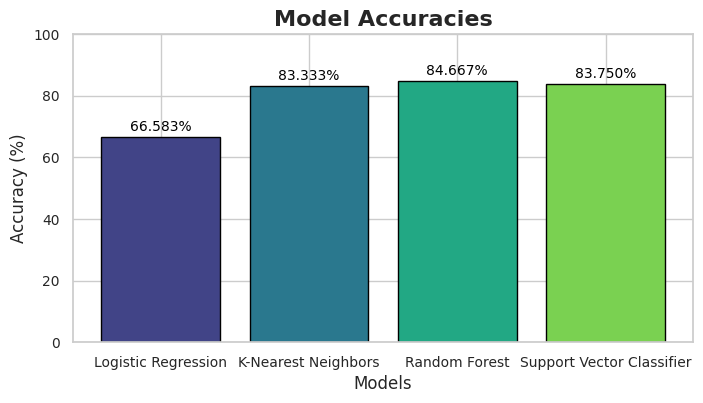

In [39]:
# using seaborn for better visualizaition
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 4))
bars = plt.bar(accuracies.keys(), accuracies.values(), color=sns.color_palette("viridis", len(accuracies)), edgecolor='black')

# adding titles and labels
plt.title('Model Accuracies', fontsize=16, weight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xlabel('Models', fontsize=12)
plt.ylim(0, 100)
plt.xticks(rotation=360, fontsize=10)
plt.yticks(fontsize=10)

# adding values above the bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{bar.get_height():.3f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.show()